In [1]:
from datetime import datetime
from graf_zarr import get_graf_s3

In [2]:
# dtime = datetime(2005,  8, 28) ## Katrina
# dtime = datetime(2023, 10, 24) ## OTIS
dtime = datetime(2017,  9, 19) ## Hurricane Maria (2017)

graf_s3 = get_graf_s3(dtime)
print(f's3://{graf_s3}/mpasout_05m.zarr/')

s3://twc-graf-reforecast/2017091912_27/mpasout_05m.zarr/


In [19]:
from mpasviewer import scvtmesh
import cartopy.crs as ccrs
from earthcmap import escmap

In [ ]:
path2data = 'sample_data'
mpasd = scvtmesh(grid_file=f'{path2data}/GRAF_15km-04km/rpm4km.static.nc',
                 diag_list=f's3://{graf_s3}/mpasout_05m.zarr/')

In [ ]:
mpasd.dataset(load_variables=['apcp_bucket',])

In [6]:
dta = mpasd.load()

In [7]:
times = sorted([str(x) for x in dta['time'].data.astype('datetime64[s]')])
num_steps = len(times)
vars = ['apcp_bucket']
print(*times, sep = ", ")

2017-09-19T12:00:00,2017-09-19T12:05:00,2017-09-19T12:10:00,2017-09-19T12:15:00,2017-09-19T12:20:00,2017-09-19T12:25:00,2017-09-19T12:30:00,2017-09-19T12:35:00,2017-09-19T12:40:00,2017-09-19T12:45:00,2017-09-19T12:50:00,2017-09-19T12:55:00,2017-09-19T13:00:00,2017-09-19T13:05:00,2017-09-19T13:10:00,2017-09-19T13:15:00,2017-09-19T13:20:00,2017-09-19T13:25:00,2017-09-19T13:30:00,2017-09-19T13:35:00,2017-09-19T13:45:00,2017-09-19T13:50:00,2017-09-19T13:55:00,2017-09-19T14:00:00,2017-09-19T14:05:00,2017-09-19T14:10:00,2017-09-19T14:15:00,2017-09-19T14:20:00,2017-09-19T14:25:00,2017-09-19T14:30:00,2017-09-19T14:35:00,2017-09-19T14:40:00,2017-09-19T14:45:00,2017-09-19T14:50:00,2017-09-19T14:55:00,2017-09-19T15:00:00,2017-09-19T15:05:00,2017-09-19T15:10:00,2017-09-19T15:15:00,2017-09-19T15:20:00,2017-09-19T15:25:00,2017-09-19T15:30:00,2017-09-19T15:35:00,2017-09-19T15:40:00,2017-09-19T15:45:00,2017-09-19T15:50:00,2017-09-19T15:55:00,2017-09-19T16:00:00,2017-09-19T16:05:00,2017-09-19T16:10:00,

In [8]:
# lo = -97.78; la=16.94 ## OTIS
# lo = -88.73; la=29.66 ## Katrina
lo = -66.49; la=18.25 ## Hurricane Maria (2017)

In [15]:
cmap, norm = escmap("mrms_prec", units="mm")

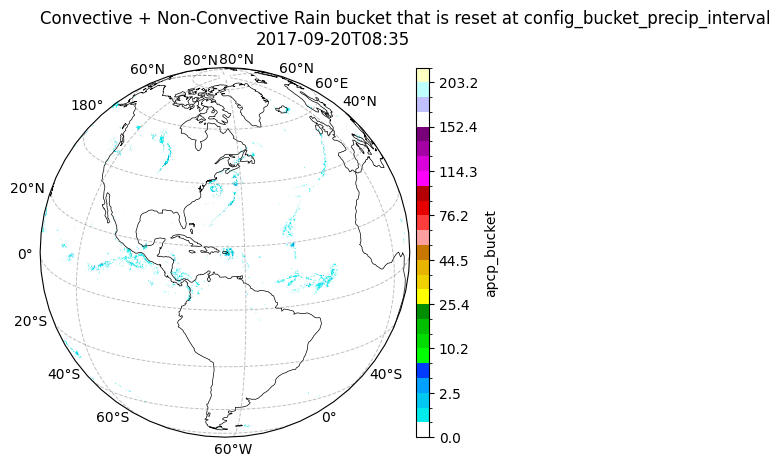

In [20]:
mpasd.show(dta,var_name='apcp_bucket',time_index='2017-09-20T08:35:00', crs=ccrs.Orthographic(central_longitude=lo, central_latitude=la), cmap = cmap, norm = norm)

In [10]:
subd = mpasd.get_subset(dta, lon = (-72.56, -59.17), lat = (12.16, 23.49))
# subd

In [12]:
from ipywidgets import interact, Dropdown, SelectionSlider
from IPython.display import display, clear_output

In [16]:
def update_plot(variable, time_step):
    mpasd.show(subd, var_name = variable, time_index=time_step, cmap = cmap, norm = norm, figsize = (9,9))
# dropdown and slider widgets
variable_dropdown = Dropdown(options=vars, description='Variable:')
time_slider = SelectionSlider(
    options=times,
    value=times[5],
    description='Datetime:',
    layout={'width': '500px'},
    style={'description_width': 'initial'}
)

In [17]:
interact(update_plot, variable=variable_dropdown, time_step=time_slider)

interactive(children=(Dropdown(description='Variable:', options=('apcp_bucket',), value='apcp_bucket'), Select…

<function __main__.update_plot(variable, time_step)>